In [1]:
import kagglehub

path = kagglehub.dataset_download("chetankv/dogs-cats-images")

print("Path to dataset files:", path)


100%|██████████| 435M/435M [00:05<00:00, 84.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/chetankv/dogs-cats-images/versions/1


In [2]:
import tensorflow as tf
print(tf.version.VERSION)
print("Dispositivos disponibles:", tf.config.list_physical_devices('GPU'))

2.19.0
Dispositivos disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [10]:
path = path + '/dataset'
os.listdir(path)

['training_set', 'test_set']

Separar imágenes de entrenamiento, validación y test

In [15]:
train_dir = os.path.join(path, 'training_set')
test_dir = os.path.join(path, 'test_set')

In [12]:
import tensorflow as tf

BATCH_SIZE = 32
IMAGE_SIZE = 150

# Dividiremos el dataset de entrenamiento y asignamos un 80% a validación
train_ds,validation_ds = tf.keras.utils.image_dataset_from_directory(
  train_dir,
  validation_split=0.2, # 20% validación
  subset="both", # devolvemos ambos datasets resultantes (train,validation)
  seed=123,
  batch_size=BATCH_SIZE)

# test dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
  test_dir,
  seed=1234,
  shuffle=False,
  batch_size=BATCH_SIZE)


Found 8000 files belonging to 2 classes.
Using 6400 files for training.
Using 1600 files for validation.
Found 2000 files belonging to 2 classes.


In [16]:
class_names = train_ds.class_names
class_names # Imprimimos clases (labels) de imágenes encontradas

['cats', 'dogs']

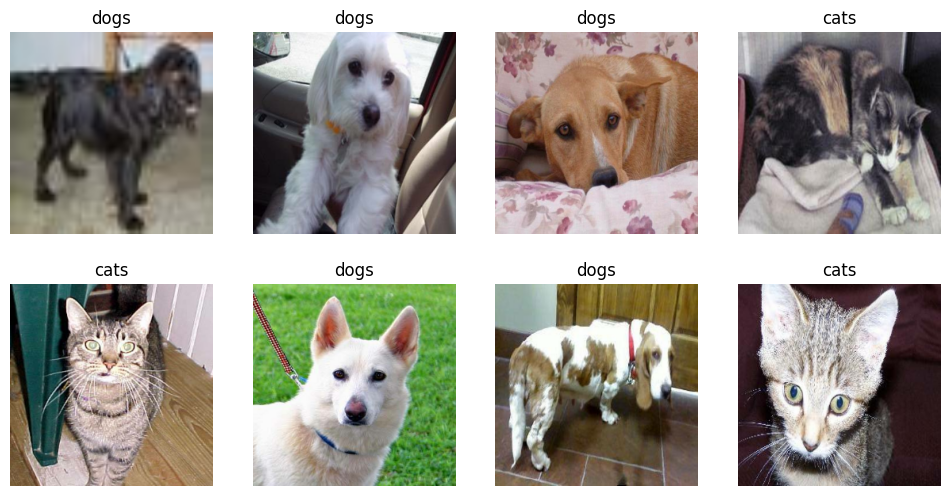

In [14]:
image_batch, label_batch = next(iter(train_ds)) # Obtenemos el primer lote de imágenes (32)

from matplotlib import pyplot as plt
plt.figure(figsize=(12, 6))
for i in range(8):  # Mostramos las 8 primeras imágenes del lote
  ax = plt.subplot(2, 4, i + 1)
  plt.imshow(image_batch[i].numpy().astype("uint8"))
  label = label_batch[i]
  plt.title(class_names[label])
  plt.axis("off")

## Construyendo el modelo

In [17]:
# Cada vez que hagamos cambios en el modelo, debemos ejecutar esto primero
tf.keras.backend.clear_session()

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Resizing, Rescaling, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, RandomRotation, RandomTranslation, RandomZoom, RandomFlip, BatchNormalization

# define model
model = Sequential([
    Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)), # Define los datos de entrada
    Resizing(IMAGE_SIZE, IMAGE_SIZE), # Integramos el escalado de las imágenes en el modelo
    Rescaling(1./255), # Normalizamos en el modelo
    Conv2D(filters=64, kernel_size=(3,3), activation='relu'), # 148x148
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2),strides=(2,2)), # 74x74

    Conv2D(filters=64, kernel_size=(3,3), activation='relu'), # 72x72
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2),strides=(2,2)), # 36x36

    Conv2D(filters=32, kernel_size=(3,3), activation='relu'), # 34x34
    MaxPooling2D(pool_size=(2,2),strides=(2,2)), # 17x17
    BatchNormalization(),
    Dropout(0.3),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(1, activation='sigmoid') # La clasificación es binaria
])

In [19]:
# compile model
model.compile(optimizer = tf.optimizers.Adam(),
    loss = 'binary_crossentropy', # Función de pérdida en clasificación binaria
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 17, 17, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 17, 17, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9248)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,367,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,849 (9.26 MB)

 Trainable params: 2,426,017 (9.25 MB)

 Non-trainable params: 832 (3.25 KB)

In [20]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

# Monitoreamos la pérdida en la validación. Detenemos después de 6 iteraciones sin mejorar. Restauramos mejores pesos
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',   # Monitorea la pérdida en validación
    factor=0.5,           # Reduce la tasa de aprendizaje a la mitad
    patience=3,           # Espera 3 iteraciones sin mejora antes de reducir
    min_lr=1e-6           # No permite que la tasa de aprendizaje baje de 1e-6
)

# Pipeline optimizado y sin Warnings
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    train_ds
    .ignore_errors() # Nueva versión
    .prefetch(buffer_size=AUTOTUNE)
)

validation_ds = (
    validation_ds
    .ignore_errors() # Nueva versión
    .prefetch(buffer_size=AUTOTUNE)
)

history = model.fit(train_ds,
        epochs = 30,
        validation_data=(validation_ds),
        callbacks=[early_stop, reduce_lr]  # Agregar ambas estrategias
)

Epoch 1/30
    200/Unknown 20s 46ms/step - accuracy: 0.5923 - loss: 0.9367

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


200/200 ━━━━━━━━━━━━━━━━━━━━ 23s 61ms/step - accuracy: 0.5925 - loss: 0.9359 - val_accuracy: 0.5656 - val_loss: 0.6754 - learning_rate: 0.0010
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.7070 - loss: 0.5837 - val_accuracy: 0.6244 - val_loss: 0.6820 - learning_rate: 0.0010
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.7774 - loss: 0.4687 - val_accuracy: 0.7081 - val_loss: 0.6022 - learning_rate: 0.0010
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - accuracy: 0.8193 - loss: 0.3996 - val_accuracy: 0.7119 - val_loss: 0.6811 - learning_rate: 0.0010
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step - accuracy: 0.8473 - loss: 0.3473 - val_accuracy: 0.7319 - val_loss: 0.5423 - learning_rate: 0.0010
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 28s 142ms/step - accuracy: 0.8838 - loss: 0.2796 - val_accuracy: 0.7544 - val_loss: 0.6008 - learning_rate: 0.0010
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - accuracy: 0.9097 - loss: 0.221

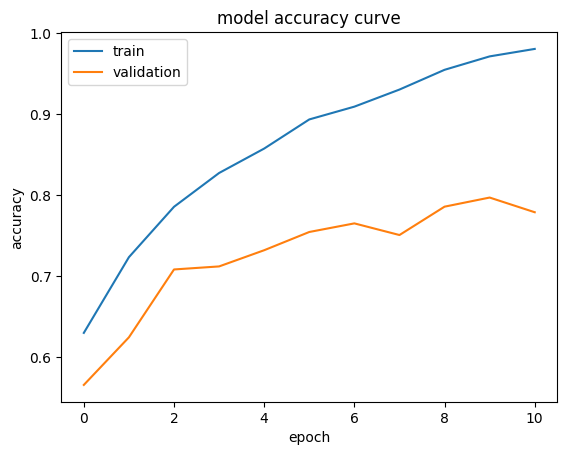

In [21]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy curve')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

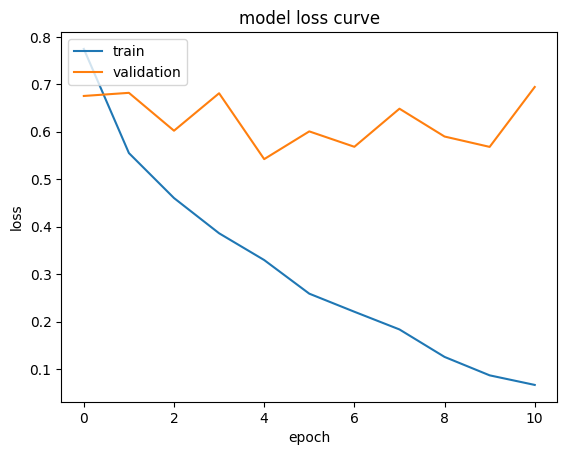

In [22]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss curve')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [23]:
# Aplicamos la misma lógica para que no se detenga el proceso
test_ds_limpio = test_ds.ignore_errors().prefetch(buffer_size=tf.data.AUTOTUNE)

# Ahora evaluamos
results = model.evaluate(test_ds_limpio)
print(f"Loss: {results[0]}, Accuracy: {results[1]}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.8127 - loss: 0.4425
Loss: 0.5468244552612305, Accuracy: 0.7555000185966492


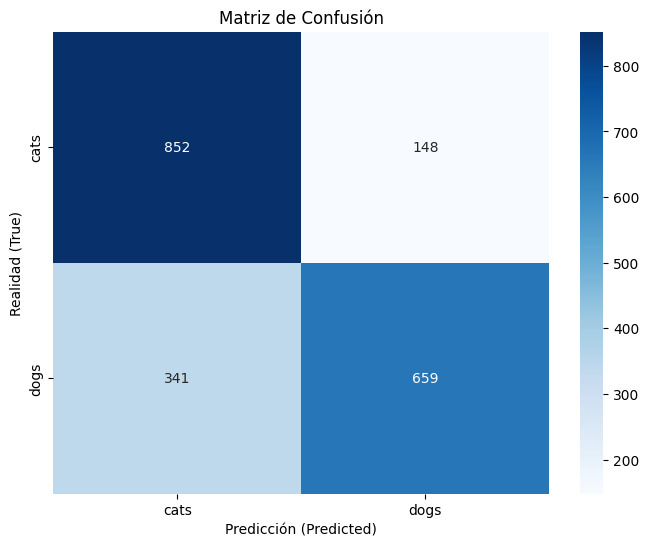

              precision    recall  f1-score   support

        cats       0.71      0.85      0.78      1000
        dogs       0.82      0.66      0.73      1000

    accuracy                           0.76      2000
   macro avg       0.77      0.76      0.75      2000
weighted avg       0.77      0.76      0.75      2000



In [24]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Recuperar los nombres de las clases del dataset ORIGINAL
# (Suponiendo que test_ds fue creado con image_dataset_from_directory)
labels_names = test_ds.class_names

# 2. Obtener las predicciones y las etiquetas reales de forma sincronizada
y_true = []
y_pred_probs = []

# Iteramos sobre el dataset limpio para asegurar que solo procesamos lo que NO está corrupto
for images, labels in test_ds_limpio:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred_probs.extend(preds.ravel())

y_true = np.array(y_true)
y_pred = (np.array(y_pred_probs) > 0.5).astype(int)

# 3. Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_names,
            yticklabels=labels_names)
plt.title("Matriz de Confusión")
plt.ylabel("Realidad (True)")
plt.xlabel("Predicción (Predicted)")
plt.show()

# 4. Reporte de Clasificación (Precisión, Recall, F1)
print(classification_report(y_true, y_pred, target_names=labels_names))

Número total de imágenes mal clasificadas: 489


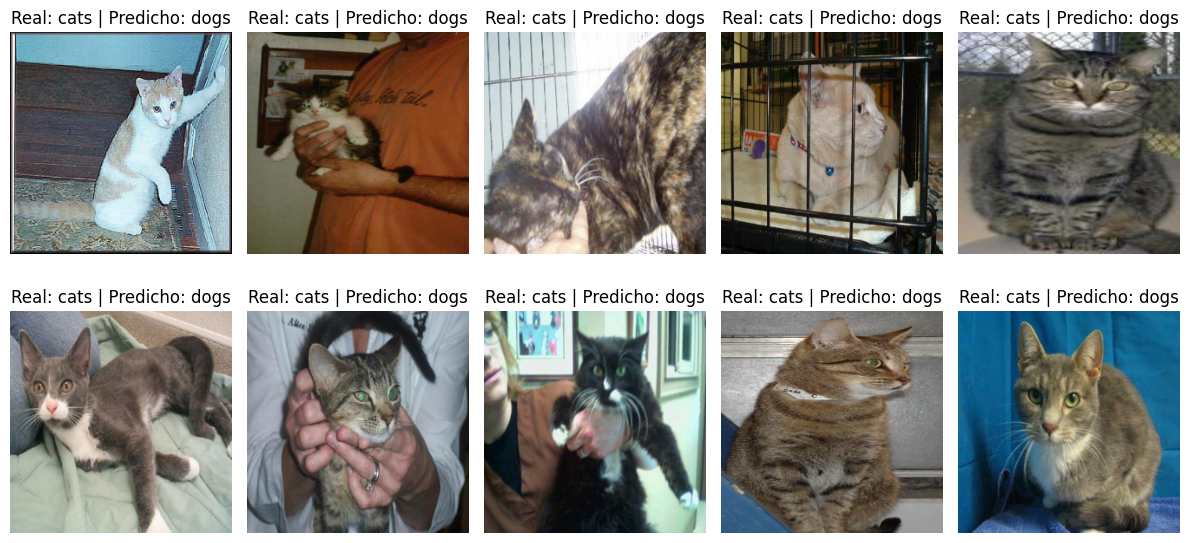

In [25]:
# Identificar los índices de las imágenes que se han clasificado incorrectamente
incorrect_indices = np.where(y_pred != y_true)[0]

print("Número total de imágenes mal clasificadas:", len(incorrect_indices))
num_show=10
index_show=incorrect_indices[:num_show]
single_element_ds = test_ds.unbatch()

# # Obtener la imagen en la posición 36 (indexada desde 0)

plt.figure(figsize=(12, 6))
for i in range(len(index_show)):
    index = index_show[i];
    imagen, etiqueta = list(single_element_ds.skip(index).take(1))[0]
    plt.subplot(2, (num_show + 1) // 2, i + 1)
    plt.imshow(imagen.numpy().astype("uint8"))
    plt.title(f"Real: {class_names[etiqueta]} | Predicho: {class_names[y_pred[index]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [26]:
import numpy as np
def classify(image_path):
  image = tf.keras.utils.load_img(image_path, color_mode='rgb')
  display(image)
  input_arr = tf.keras.utils.img_to_array(image)
  input_arr = np.array([input_arr])
  print(f'Tamaño de entrada: {input_arr.shape}')
  y_pred = model.predict(input_arr)
  print(f'Valores de salida: {y_pred[0][0]}')
  predicted_category_classname = class_names[round(y_pred[0][0])]
  print(f'Clasificación: {predicted_category_classname}')

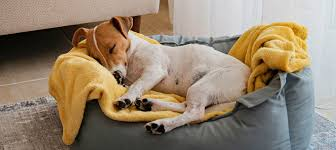

Tamaño de entrada: (1, 150, 336, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Valores de salida: 0.4330626428127289
Clasificación: cats


In [32]:
classify('dog3.jpg')